# Desafío: Preparación de datos y gráficos
## Daniel Rojas López

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de salarios
df = pd.read_csv("world-data-2023.csv",delimiter=',')
df.shape

(195, 35)

In [10]:
df.head(5)

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887


In [3]:
df.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

1. Carga los datos y genera un dataFrame que excluya las columnas correspondientesa la abreviatura del país, código de llamada, capital, código de moneda, ciudad más grande, lenguaje oficial, latitud y longitud. Considerando estos datos, realiza una inspección inicial sobre ellos, considerando gráficos. Concluye.


In [4]:
#1. Carga los datos y genera un dataFrame que excluya las columnas correspondientes a la 
# abreviatura del país,
# código de llamada,
# capital, 
# código de moneda,
# ciudad más grande, 
# lenguaje oficial, 
# latitud y longitud. 

# Considerando estos datos, realiza una inspección inicial sobre ellos, considerando gráficos. Concluye.

# Excluir las columnas especificadas
columns_to_exclude = [
    'Abbreviation',
    'Calling Code',
    'Capital/Major City',
    'Currency Code',
    'Official language',
    'Latitude',
    'Longitude'
]

# Filtrar las columnas que no están en la lista de exclusiones
df_filtered = df.drop(columns=[col for col in columns_to_exclude if col in df.columns])
df_filtered.head(10)


,Country,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Currency-Code,...,Maternal mortality ratio,Minimum wage,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population
0,Afghanistan,60,58.10%,"652,230","323,000",32.49,"8,672",149.9,2.30%,AFN,...,638.0,$0.43,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273"
1,Albania,105,43.10%,"28,748","9,000",11.78,"4,536",119.05,1.40%,ALL,...,15.0,$1.12,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593"
2,Algeria,18,17.40%,"2,381,741","317,000",24.28,"150,006",151.36,2.00%,DZD,...,112.0,$0.95,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100"
3,Andorra,164,40.00%,468,NaN,7.20,469,NaN,NaN,EUR,...,NaN,$6.63,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873"
4,Angola,26,47.50%,"1,246,700","117,000",40.73,"34,693",261.73,17.10%,AOA,...,241.0,$0.71,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025"
5,Antigua and Barbuda,223,20.50%,443,0,15.33,557,113.81,1.20%,XCD,...,42.0,$3.04,24.30%,2.76,"97,118",NaN,16.50%,43.00%,NaN,"23,800"
6,Argentina,17,54.30%,"2,780,400","105,000",17.02,"201,348",232.75,53.50%,ARS,...,39.0,$3.35,17.60%,3.96,"44,938,712",61.30%,10.10%,106.30%,9.79%,"41,339,571"
7,Armenia,104,58.90%,"29,743","49,000",13.99,"5,156",129.18,1.40%,AMD,...,26.0,$0.66,81.60%,4.40,"2,957,731",55.60%,20.90%,22.60%,16.99%,"1,869,848"
8,Australia,3,48.20%,"7,741,220","58,000",12.60,"375,908",119.8,1.60%,AUD,...,6.0,$13.59,19.60%,3.68,"25,766,605",65.50%,23.00%,47.40%,5.27%,"21,844,756"
9,Austria,109,32.40%,"83,871","21,000",9.70,"61,448",118.06,1.50%,EUR,...,5.0,NaN,17.90%,5.17,"8,877,067",60.70%,25.40%,51.40%,4.67%,"5,194,416"


In [18]:
#df_filtered.describe()
#df_filtered['Population'].describe()
df_filtered['Life expectancy'].describe()


count    187.000000
mean      72.279679
std        7.483661
min       52.800000
25%       67.000000
50%       73.200000
75%       77.500000
max       85.400000
Name: Life expectancy, dtype: float64

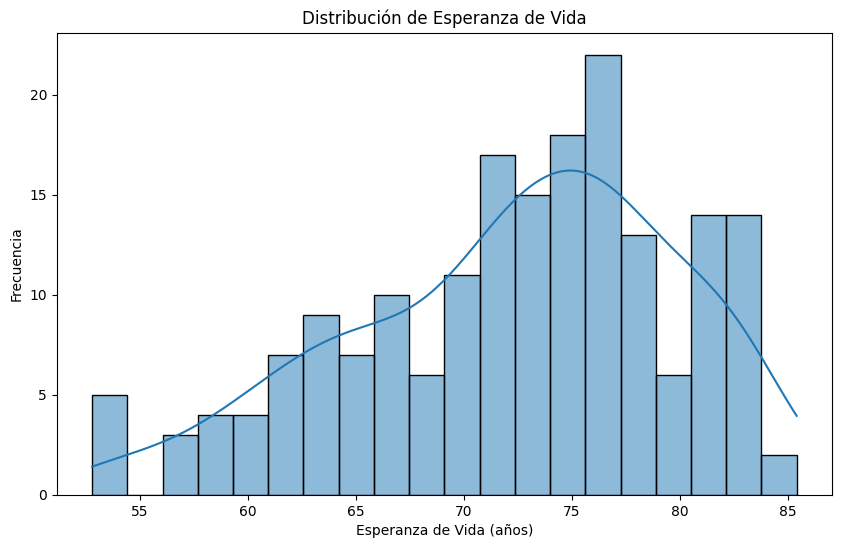

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['Life expectancy'], bins=20, kde=True)
plt.title('Distribución de Esperanza de Vida')
plt.xlabel('Esperanza de Vida (años)')
plt.ylabel('Frecuencia')
plt.show()

Como se observa en el gráfico histograma se puede decir que
la mayoría de los pacientes tienen una edad entre 67 y 77.5 años.
}
- Rango típico: 67-77.5 años (25%-75%)
- Promedio: 72.28 años
- Valores extremos: <60 años o >80 años


2. De las variables codificadas numéricamente, ¿hay pares de ellas en la que parezca haber correlación? ¿Para cuál(es) de ellas se observa más claramente?

In [ ]:
#2. De las variables codificadas numéricamente, ¿hay pares de ellas en la que parezca haber correlación? ¿Para cuál(es) de ellas se observa más claramente?




3. Considera los dos pares de variables anteriores y elimina en cada caso los faltantes
y atípicos. Justifica en cada caso tu procedimiento.
4. Construye un gráfico para verificar la correlación entre estas variables, ahora con los
datos preparados. Compara con lo obtenido anteriormente.
5. Realiza lo mismo para comparar la cantidad de médicos por cada mil personas y la
esperanza de vida. ¿Qué puedes concluir?
6. Construye un gráfico para representar la población total de los países y su producto
interno bruto. Prepara los datos y escoge el gráfico adecuado (si es necesario, limpia
y/o transforma los datos). Justifica
7. Escoge otro par de datos, límpialos, prepáralos y analiza su posible relación. Justifica
utilizando las herramientas vistas y gráficos adecuados
